<a href="https://colab.research.google.com/github/srijalgiri/Ai-ML_sem6/blob/main/Worksheet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

<h1> Task1</h1>

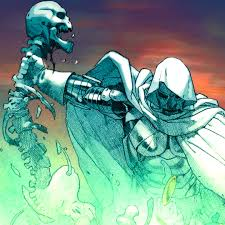

In [13]:
image = Image.open("/content/drive/MyDrive/doom.png")
image

<h1>Display only the top left corner of 100x100 pixels.</h1>

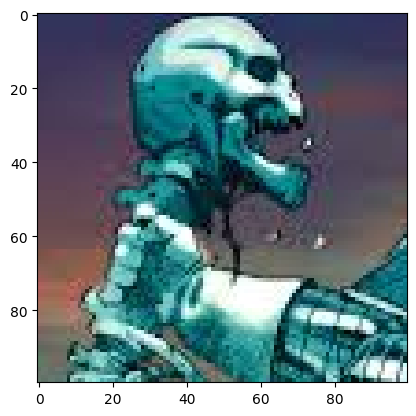

In [14]:
image_array = np.array(image)
corner_img = image_array[0:100, 0:100]
plt.imshow(corner_img)
plt.show()

<h1>Show the three color channels</h1>

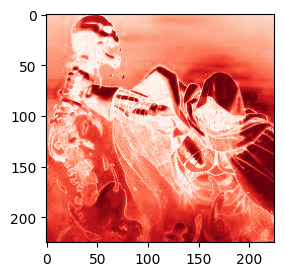

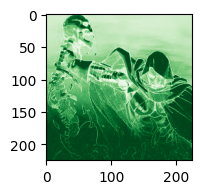

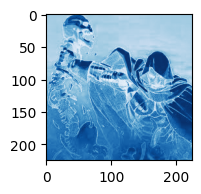

In [15]:
R = image_array[:,:,0]
G = image_array[:,:,1]
B = image_array[:,:,2]

plt.figure(figsize=(10,10))
plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.show()

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.show()

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.show()

<h1>Modify the top 100 × 100 pixels to a value of 210 and display the resulting image</h1>

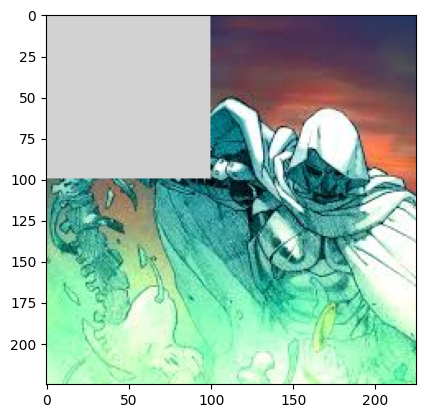

In [16]:
image_array[0:100, 0:100] = 210
plt.imshow(image_array)
plt.show()


<h1>Task 2 </h1>

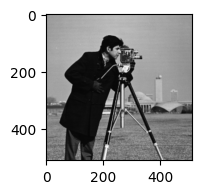

In [17]:
image = Image.open("/content/drive/MyDrive/cameraman.png")
plt.subplot(1,3,1)
plt.imshow(image, cmap="grey")
plt.show()

<h1>Extract and display the middle section of the image (150 pixels)</h1>

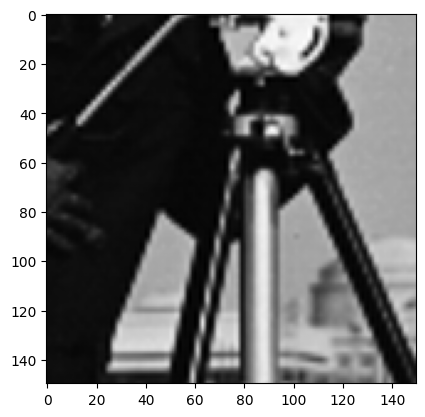

In [18]:
image_array = np.array(image)
h, w= image_array.shape

center_h = h // 2
center_w = w // 2
center_h,center_w

center_crop = image_array[center_h-75:center_h+75, center_w-75:center_w+75]
center_crop

plt.imshow(center_crop, cmap="gray")
plt.show()

<h1>Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0)</h1>

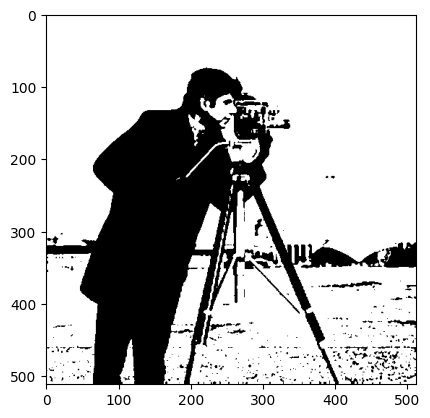

In [19]:
binary_image = np.where(image_array < 100, 0, 255)
plt.imshow(binary_image, cmap="gray")
plt.show()

<h1>Rotate the image 90 degrees clockwise and display the result</h1>

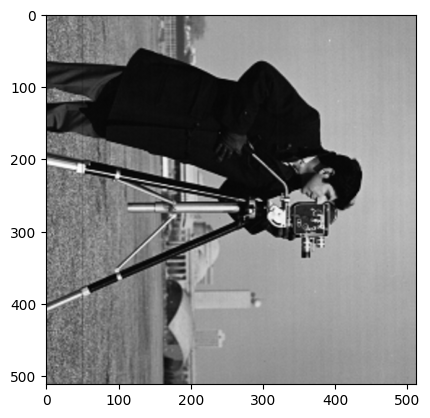

In [20]:
rotated_image = image.rotate(-90, expand=True)
plt.imshow(rotated_image, cmap="gray")
plt.show()

<h1>Convert the grayscale image to an RGB image</h1>

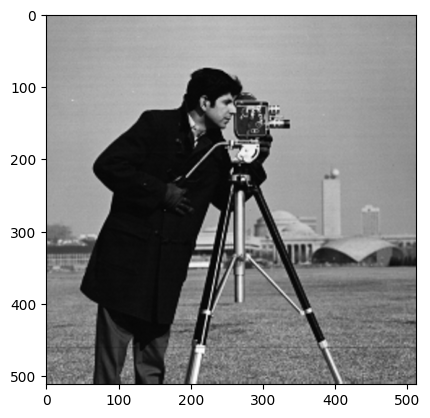

In [21]:
rgb_image = np.stack((image_array,)*3, axis=-1)
plt.imshow(rgb_image)
plt.show()

<h1>Task3</h1>

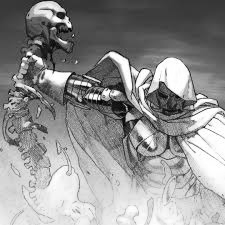

In [23]:
image = Image.open("/content/drive/MyDrive/doom.png").convert("L")
image

In [30]:
image_array = np.array(image)



In [28]:

cov_matrix = np.cov(stan_data)
image_array.shape


(225, 225)

In [29]:

cov_matrix.shape


(225, 225)

<h1>Eigen Decomposition and Identifying Principal Components</h1>

In [32]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

sorted_index = np.argsort(eigenvalues)[::-1]

sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]

eigenvalues

array([ 2.30860844e+01,  1.30821678e+01,  9.73006920e+00,  5.38034946e+00,
        4.17305904e+00,  3.61834739e+00,  2.96140855e+00,  2.93660372e+00,
        2.40444838e+00,  1.94473504e+00,  1.70924631e+00,  1.51559084e+00,
        1.44065905e+00,  1.35661105e+00,  1.20303893e+00,  1.03342145e+00,
        9.55148724e-01,  9.00321001e-01,  8.54044177e-01,  8.13799670e-01,
        7.48928165e-01,  6.87193142e-01,  6.43836670e-01,  6.21217972e-01,
        5.95407428e-01,  5.76229798e-01,  4.99462756e-01,  4.90944224e-01,
        4.69837637e-01,  4.32643814e-01,  4.22672848e-01,  3.96792305e-01,
        3.68551604e-01,  3.45101634e-01,  3.31385388e-01,  3.33826961e-01,
        3.03273002e-01,  3.14606054e-01,  3.17030608e-01,  2.89250905e-01,
        2.84905534e-01,  2.75031277e-01,  2.68207154e-01,  2.49410644e-01,
        2.43719670e-01,  2.36012148e-01,  2.26555059e-01,  2.24914772e-01,
        2.19416853e-01,  2.16021444e-01,  1.96161714e-01,  1.90547540e-01,
        1.87408456e-01,  

In [33]:
eigenvectors

array([[ 0.00501391, -0.00018559, -0.02279944, ..., -0.13009972,
         0.02905836,  0.06134874],
       [ 0.00636572,  0.00534119,  0.07455407, ..., -0.15859362,
         0.10992094, -0.0759404 ],
       [ 0.00920044,  0.01182057,  0.1402277 , ...,  0.03924486,
        -0.10494327,  0.00794146],
       ...,
       [ 0.0310907 , -0.00197986, -0.01031259, ..., -0.01891834,
         0.04616895,  0.10622945],
       [ 0.03028977, -0.00039108, -0.00628528, ...,  0.04721308,
        -0.02989874, -0.07532367],
       [ 0.02101806, -0.00183626, -0.00122148, ..., -0.05608552,
         0.03052805,  0.01802771]])

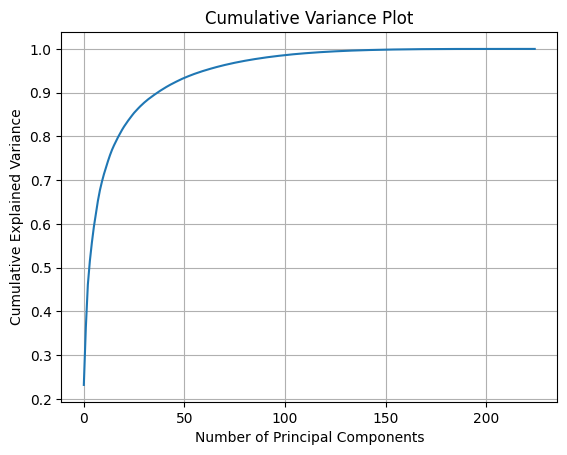

In [35]:
k = 50

top_k_eigenvectors = sorted_eigenvectors[:, :k]
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)


cumulative_variance = np.cumsum(explained_variance)

plt.figure()
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Plot")
plt.grid()
plt.show()

<h1>Reconstruction and Experiment</h1>

In [36]:
stan_data.shape

(225, 225)

In [37]:
top_k_eigenvectors.shape

(225, 50)

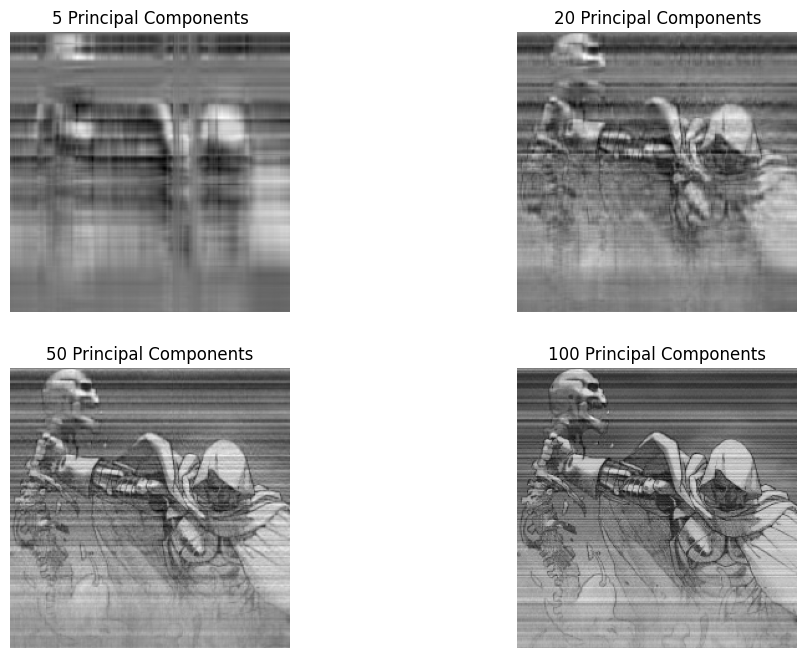

In [39]:
Z = stan_data.T @ top_k_eigenvectors
reconstructed = (Z @ top_k_eigenvectors.T).T

# restore original scale
reconstructed = reconstructed * std + mean

k_values = [5, 20, 50, 100]

plt.figure(figsize=(12,8))

for i, k in enumerate(k_values):

    W_k = sorted_eigenvectors[:, :k]

    # projection
    Z = stan_data.T @ W_k

    # reconstruction
    reconstructed = Z @ W_k.T
    reconstructed = reconstructed.T

    reconstructed = reconstructed * std + mean

    # remove imaginary part
    reconstructed = np.real(reconstructed)

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"{k} Principal Components")
    plt.axis("off")

plt.show()

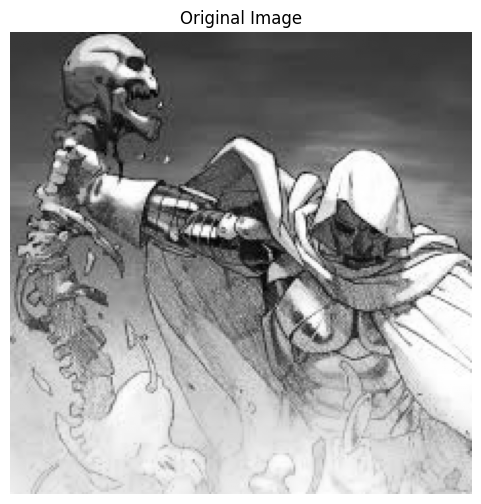

In [40]:
plt.figure(figsize=(6,6))
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()